# Forecasting Hung Councils in the 2026 Local Government Elections
**DIRISA Student Datathon Challenge 2026 — Machine Learning**

### Objective
Our EDA showed that South African local politics has become far more fragmented: one-party-dominant municipalities fell from 70% in 2000 to 18% in 2021. A direct consequence is the rise of **hung councils**, where no party wins a majority and a coalition must be formed. Coalitions have been linked to unstable governance and service-delivery disruption in several metros.

This notebook answers two questions:
1. **What types of municipality exist?** We use **KMeans clustering** to discover competition regimes from the data.
2. **Which municipalities are likely to have a hung council after the 4 November 2026 election?** We train and compare several models, including **XGBoost**, to predict each municipality's outcome at the *next* election from what we know about it *now*, and select the one that would have forecast past elections best.

### Why the two models have different jobs
Our first prototype used KMeans to label municipalities and then trained XGBoost to predict those same labels from the same features. XGBoost scored about 99%, but only because the labels were built from its own inputs, so it was **recovering a rule rather than predicting anything** (a form of target leakage). In this notebook, KMeans *describes* municipalities, and XGBoost *forecasts* a future outcome that is genuinely unknown at prediction time.

### Data
We use `lge_panel_2000_2021.csv`, the cleaned panel produced by our EDA notebook: one row per municipality per election (2000, 2006, 2011, 2016, 2021), with municipalities linked across elections despite boundary changes. Source: Electoral Commission of South Africa (IEC).

In [1]:
# Libraries used in this notebook (see References at the end).
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, average_precision_score, balanced_accuracy_score,
                             brier_score_loss, confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve, silhouette_score,
                             accuracy_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedGroupKFold, cross_val_predict,
                                     cross_validate)
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from scipy.special import logit
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
SEED = 42   # one fixed seed for every random step, so results are reproducible

In [2]:
# Paths are relative to the project folder; the panel dataset is created by the EDA notebook.
# It works whether Jupyter is opened in the notebooks/ folder or in the project root.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL_FILE = PROJECT_DIR / "outputs" / "lge_panel_2000_2021.csv"
FIG_DIR = PROJECT_DIR / "figures"
MODEL_DIR = PROJECT_DIR / "models"
OUT_DIR = PROJECT_DIR / "outputs"
for folder in (FIG_DIR, MODEL_DIR, OUT_DIR):
    folder.mkdir(exist_ok=True)
assert PANEL_FILE.exists(), "Run the EDA notebook first: it creates outputs/lge_panel_2000_2021.csv"

YEARS = [2000, 2006, 2011, 2016, 2021]
panel = pd.read_csv(PANEL_FILE)
print(f"Panel loaded: {len(panel):,} municipality-elections, {panel['panel_id'].nunique()} municipalities")
panel.groupby("year").size().to_frame("municipalities").T

Panel loaded: 1,134 municipality-elections, 263 municipalities


year,2000,2006,2011,2016,2021
municipalities,237,237,234,213,213


## Part A — What types of municipality exist? (KMeans clustering)

KMeans groups municipalities that look similar, without being told the categories in advance. We describe each municipality-election with three **competition measures only**:

| Feature | Meaning |
|---|---|
| `enp` | Effective Number of Parties, $1 / \sum_i s_i^2$ (Laakso & Taagepera, 1979) |
| `top_share` | Vote share of the leading party |
| `margin` | Share of 1st party − share of 2nd party |

We deliberately **exclude turnout**: our EDA found it is only weakly related to competition, and 2016 turnout in the cleaned data is not a valid turnout measure (see the EDA notebook). Features are standardised first, because KMeans measures distance and would otherwise be dominated by whichever feature has the largest numbers.

To stop the 2021 test election from influencing the cluster definitions, we **fit KMeans on 2000–2016 only** and then assign 2021 municipalities to the nearest learned cluster.

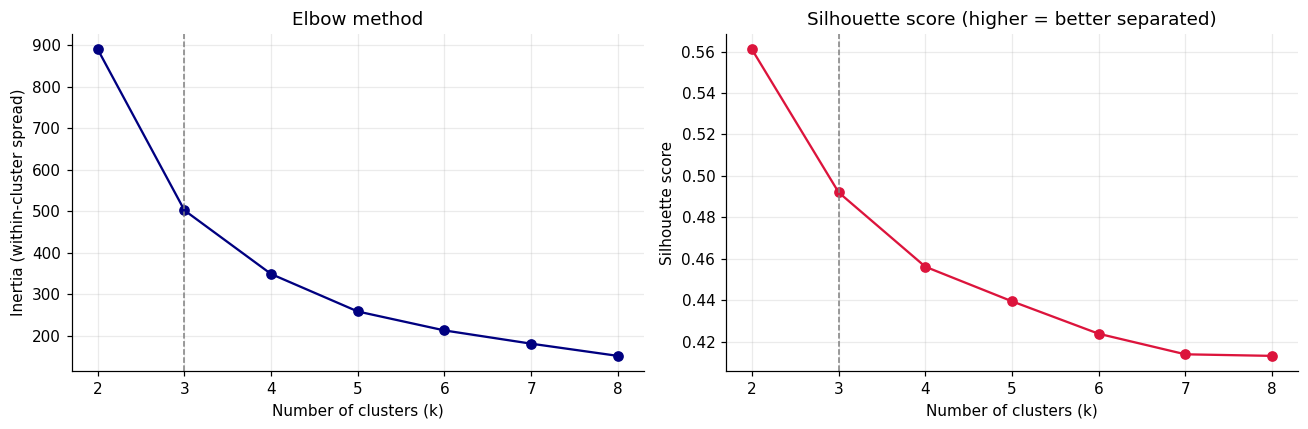

k,2,3,4,5,6,7,8
inertia,889.528,502.047,348.706,258.519,212.890,181.007,151.620
silhouette,0.561,0.492,0.456,0.439,0.424,0.414,0.413


In [3]:
# Competition features only; KMeans is fitted on 2000–2016 so 2021 stays unseen.
CLUSTER_FEATURES = ["enp", "top_share", "margin"]
fit_rows = panel["year"] < 2021

scaler = StandardScaler().fit(panel.loc[fit_rows, CLUSTER_FEATURES])
X_cluster = scaler.transform(panel.loc[fit_rows, CLUSTER_FEATURES])

# We try k = 2 to 8 and record two quality measures for each.
k_values = range(2, 9)
inertia, silhouette = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(X_cluster)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertia, "o-", color="navy")
axes[0].set(xlabel="Number of clusters (k)", ylabel="Inertia (within-cluster spread)", title="Elbow method")
axes[1].plot(k_values, silhouette, "o-", color="crimson")
axes[1].set(xlabel="Number of clusters (k)", ylabel="Silhouette score", title="Silhouette score (higher = better separated)")
for ax in axes:
    ax.axvline(3, color="grey", ls="--", lw=1)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_01_choosing_k.png", dpi=200, bbox_inches="tight")
plt.show()
pd.DataFrame({"k": list(k_values), "inertia": inertia, "silhouette": silhouette}).round(3).set_index("k").T

**Choosing k.** The silhouette score measures how clearly each municipality belongs to its own cluster rather than a neighbouring one (Rousseeuw, 1987). The elbow chart shows where adding more clusters stops reducing the spread much. k = 2 has the highest silhouette score, but it only splits municipalities into "dominant" and "not dominant". We choose **k = 3**: it sits at the elbow of the inertia curve, still has a reasonable silhouette score (about 0.49), and gives three groups that map directly onto our research framing (dominant, competitive, fragmented). Larger values of k lower the silhouette score further and split the same groups into finer slices.

In [4]:
# Final KMeans with k = 3. We name clusters by their average ENP, from lowest to highest.
kmeans = KMeans(n_clusters=3, n_init=50, random_state=SEED).fit(X_cluster)
centres = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=CLUSTER_FEATURES)
order = centres["enp"].sort_values().index
REGIME_NAMES = ["Dominant", "Competitive", "Fragmented"]
cluster_to_name = {cluster: REGIME_NAMES[rank] for rank, cluster in enumerate(order)}

# Every municipality-election (including 2021) is assigned to its nearest cluster centre.
panel["regime_kmeans"] = pd.Categorical(
    pd.Series(kmeans.predict(scaler.transform(panel[CLUSTER_FEATURES]))).map(cluster_to_name).to_numpy(),
    categories=REGIME_NAMES, ordered=True)

centres.index = centres.index.map(cluster_to_name)
centres = centres.loc[REGIME_NAMES]
centres["municipality-elections"] = panel.loc[fit_rows, "regime_kmeans"].value_counts().reindex(REGIME_NAMES)
centres.round(3)

,enp,top_share,margin,municipality-elections
Dominant,1.458,0.822,0.718,333
Competitive,1.960,0.670,0.441,327
Fragmented,2.519,0.507,0.154,261


In [5]:
# Stability check: if the clusters are real, different random starts should find the same groups.
reference = kmeans.labels_
ari_scores = [adjusted_rand_score(reference, KMeans(n_clusters=3, n_init=10, random_state=s).fit(X_cluster).labels_)
              for s in range(20)]
print(f"Stability across 20 random starts: mean ARI = {np.mean(ari_scores):.3f} (1.0 = identical clusters)")

# How do the data-driven clusters compare with the fixed ENP thresholds from our EDA?
fixed = pd.cut(panel["enp"], bins=[0, 2, 3, np.inf], right=False, labels=REGIME_NAMES)
print(f"Agreement with fixed thresholds (ENP < 2, 2–3, ≥ 3): ARI = {adjusted_rand_score(fixed, panel['regime_kmeans']):.3f}")
display(pd.crosstab(panel["regime_kmeans"], fixed, rownames=["KMeans"], colnames=["Fixed thresholds"]))

# The ENP ranges KMeans settled on show where the data itself draws the boundaries.
panel.groupby("regime_kmeans", observed=True)["enp"].describe()[["min", "25%", "50%", "75%", "max"]].round(2)

Stability across 20 random starts: mean ARI = 1.000 (1.0 = identical clusters)
Agreement with fixed thresholds (ENP < 2, 2–3, ≥ 3): ARI = 0.346


Fixed thresholds,Dominant,Competitive,Fragmented
KMeans,,,
Dominant,357,0,0
Competitive,204,179,0
Fragmented,14,287,93


,min,25%,50%,75%,max
regime_kmeans,,,,,
Dominant,1.06,1.34,1.47,1.61,1.78
Competitive,1.62,1.84,1.97,2.12,2.47
Fragmented,1.95,2.34,2.59,2.98,5.09


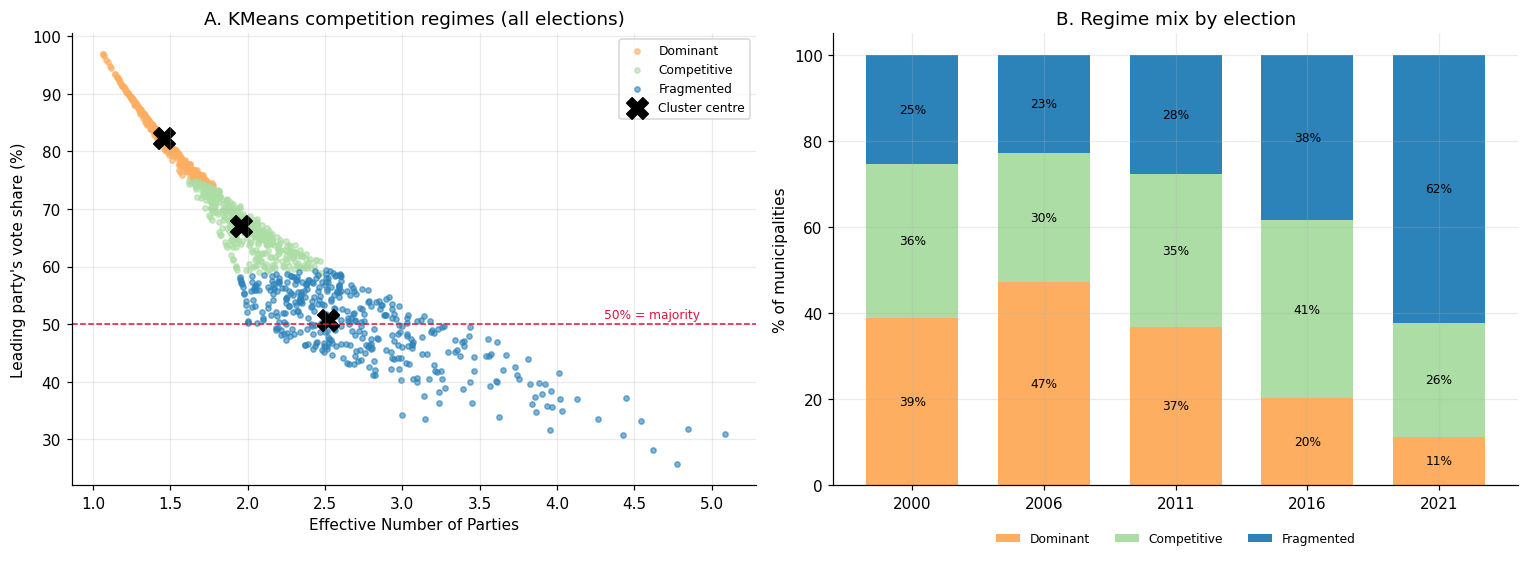

In [6]:
# Left: the clusters in competition space. Right: how the regime mix changed across elections.
colours = {"Dominant": "#fdae61", "Competitive": "#abdda4", "Fragmented": "#2b83ba"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
for name in REGIME_NAMES:
    rows = panel["regime_kmeans"] == name
    ax.scatter(panel.loc[rows, "enp"], panel.loc[rows, "top_share"] * 100, s=12, alpha=0.6,
               color=colours[name], label=name)
centre_points = centres[["enp", "top_share"]]
ax.scatter(centre_points["enp"], centre_points["top_share"] * 100, marker="X", s=200, color="black", label="Cluster centre")
ax.axhline(50, color="crimson", ls="--", lw=1)
ax.text(4.3, 51, "50% = majority", color="crimson", fontsize=8)
ax.set(xlabel="Effective Number of Parties", ylabel="Leading party's vote share (%)",
       title="A. KMeans competition regimes (all elections)")
ax.legend(fontsize=8)

ax = axes[1]
mix = pd.crosstab(panel["year"], panel["regime_kmeans"], normalize="index") * 100
mix.plot(kind="bar", stacked=True, ax=ax, color=[colours[n] for n in REGIME_NAMES], width=0.7, rot=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8)
ax.set(xlabel="", ylabel="% of municipalities", title="B. Regime mix by election")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_02_kmeans_regimes.png", dpi=200, bbox_inches="tight")
plt.show()

**Interpretation.** The three clusters are extremely stable (identical across 20 random starts, ARI = 1.00) and have a clear political meaning. **Dominant** municipalities have an average ENP of 1.46 and a leader on 82% of the vote; **Competitive** municipalities average ENP 1.96 with a leader on 67%; and **Fragmented** municipalities average ENP 2.52 with a leader on just **51%**, sitting right on the majority line. KMeans draws its boundaries at roughly ENP 1.7 and 2.2, noticeably lower than the conventional thresholds of 2 and 3 (agreement ARI = 0.35), because it also uses the leader's share and margin. In other words, the data itself suggests that a municipality becomes politically "fragmented" once its leading party drops towards 50%, which is exactly the point at which hung councils appear. Using these data-driven regimes, fragmented municipalities rose from 25% in 2000 to 62% in 2021.

## Part B — Which councils will be hung in 2026? (supervised forecasting)

### Target
A council is **hung** when no party wins a majority. We approximate this as the leading party receiving **less than 50% of the PR vote**, because council seats are allocated in proportion to PR votes. (Seat rounding can occasionally give a party at 49% a majority, so this is a close approximation rather than an exact seat count.)

### How the training data is built
Each training example is a **pair of consecutive elections**: the municipality's profile at one election (features) and whether it was hung at the **next** election (target). Nothing from the target election is used as a feature, so the model is genuinely forecasting.

| Pair | Features from | Target from | Role |
|---|---|---|---|
| 1 | 2000 | 2006 | Training |
| 2 | 2006 | 2011 | Training |
| 3 | 2011 | 2016 | Training |
| 4 | 2016 | 2021 | **Test (never seen during training or tuning)** |
| Forecast | 2021 | **2026** | Final prediction |

### Features (all known at the time of prediction)
- **Competition:** `enp`, `top_share`, `margin`, `parties_contesting`, current KMeans regime, and whether the council is already hung (`hung_now`).
- **Trend:** change in `top_share` and `enp` since the previous election, capturing momentum (missing for 2000, which has no earlier election).
- **Context:** province, metro status, municipality size (`log_valid`), and whether the ANC currently leads.

Turnout is excluded because 2016 turnout is not usable (see the EDA notebook), so it would be missing for every test example.

In [7]:
# Trend features compare each municipality with its own previous election.
panel = panel.sort_values(["panel_id", "year"]).reset_index(drop=True)
previous = panel.groupby("panel_id")[["year", "top_share", "enp"]].shift(1)
consecutive = previous["year"].map({y: n for y, n in zip(YEARS[:-1], YEARS[1:])}) == panel["year"]
panel["delta_top_share"] = np.where(consecutive, panel["top_share"] - previous["top_share"], np.nan)
panel["delta_enp"] = np.where(consecutive, panel["enp"] - previous["enp"], np.nan)

panel["hung_now"] = (panel["top_share"] < 0.5).astype(int)
panel["anc_leads"] = (panel["leading_party"] == "AFRICAN NATIONAL CONGRESS").astype(int)

# Pair each municipality-election with the SAME municipality's result at the next election.
next_election = dict(zip(YEARS[:-1], YEARS[1:]))
panel["target_year"] = panel["year"].map(next_election)
targets = panel[["panel_id", "year", "hung_now", "regime_kmeans"]].rename(
    columns={"year": "target_year", "hung_now": "hung_next", "regime_kmeans": "regime_next"})
pairs = panel.merge(targets, on=["panel_id", "target_year"], how="inner")

NUMERIC = ["enp", "top_share", "margin", "parties_contesting", "hung_now", "delta_top_share",
           "delta_enp", "log_valid", "metro", "anc_leads"]
CATEGORICAL = ["province", "regime_kmeans"]
FEATURES = NUMERIC + CATEGORICAL

pairs["regime_kmeans"] = pairs["regime_kmeans"].astype(str)
train = pairs[pairs["year"] <= 2011].reset_index(drop=True)
test = pairs[pairs["year"] == 2016].reset_index(drop=True)
forecast = panel[panel["year"] == 2021].copy()
forecast["regime_kmeans"] = forecast["regime_kmeans"].astype(str)

balance = pairs.groupby("target_year").agg(examples=("hung_next", "size"), hung=("hung_next", "sum"))
balance["% hung"] = (balance["hung"] / balance["examples"] * 100).round(1)
balance["role"] = ["Training", "Training", "Training", "Test"]
balance

,examples,hung,% hung,role
target_year,,,,
2006.0,225,30,13.3,Training
2011.0,231,33,14.3,Training
2016.0,200,25,12.5,Training
2021.0,213,72,33.8,Test


**Class imbalance and a shifting target.** Only about 13% of training examples are hung councils, but 30% of councils were hung in 2021. This matters in two ways:
1. **Accuracy is misleading.** A model that always says "not hung" would be 87% accurate on the training data. We therefore evaluate with **ROC-AUC** (how well the model ranks at-risk councils above safe ones) and **PR-AUC** (average precision, which focuses on the rare hung class; Saito & Rehmsmeier, 2015), alongside precision, recall and F1.
2. **The test is deliberately hard.** The models learn from a period when hung councils were rare and are tested on the election where they suddenly became common.

### Models compared
| Model | Features | Why we include it |
|---|---|---|
| **Persistence baseline** | Leading party's current share | No learning at all: ranks councils by how close the leader is to losing its majority. Any real model must beat this. |
| **Logistic regression (simple)** | Leading party's share only (as log-odds) | The simplest learned model; turns the baseline into realistic probabilities. The log-odds transform, $\log\frac{s}{1-s}$, is the standard scale for a share: it stretches values near 0% and 100%, so a fall from 55% to 45% counts for more than a fall from 95% to 85%. |
| **Logistic regression (full)** | All 12 features | A linear model that can also use trends, province and context. |
| **XGBoost (full)** | All 12 features | Gradient-boosted decision trees (Chen & Guestrin, 2016) that capture non-linear effects and interactions and handle missing values natively. Tuned with randomised search. |

The full models use class weighting so the rare hung class is not ignored.

In [8]:
X_train, y_train, groups = train[FEATURES], train["hung_next"], train["panel_id"]
X_test, y_test = test[FEATURES], test["hung_next"]
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Simple logistic regression: one feature (as log-odds) and no class weights, so probabilities stay realistic.
logistic_simple = Pipeline([
    ("prep", ColumnTransformer([("num", FunctionTransformer(logit), ["top_share"])])),
    ("model", LogisticRegression(max_iter=2000)),
])

# Full logistic regression: impute missing trends (with a missing flag), scale numbers, one-hot categories.
logistic_full = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                          ("scale", StandardScaler())]), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000, C=0.5)),
])

# XGBoost: trees do not need scaling and handle missing values themselves.
xgb_pipeline = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL)])),
    ("model", XGBClassifier(eval_metric="logloss", scale_pos_weight=pos_weight,
                            random_state=SEED, n_jobs=-1)),
])

### Validation step 1: grouped cross-validation (tuning XGBoost)
We tune XGBoost with **5-fold cross-validation on the training pairs only**; the 2021 test pair is never touched.

We use **`StratifiedGroupKFold`**, grouped by municipality. The same municipality appears in up to three training pairs, so ordinary cross-validation could put Johannesburg-2006 in training and Johannesburg-2011 in validation, letting the model "recognise" the municipality instead of learning general patterns. Grouping keeps each municipality entirely in one fold, and stratification keeps the share of hung councils similar in every fold.

In [9]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

# Randomised search tries 40 hyperparameter combinations, each scored by grouped cross-validation.
search_space = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__reg_lambda": [1, 5, 10],
}
search = RandomizedSearchCV(xgb_pipeline, search_space, n_iter=40, scoring="average_precision",
                            cv=cv, random_state=SEED, n_jobs=-1)
search.fit(X_train, y_train, groups=groups)
xgb_model = search.best_estimator_
print("Best XGBoost settings:", {k.replace("model__", ""): v for k, v in search.best_params_.items()})

MODELS = {"Logistic regression (simple)": logistic_simple,
          "Logistic regression (full)": logistic_full,
          "XGBoost (full)": xgb_model}

# Cross-validated performance of each model on the training pairs.
cv_results = {}
for name, model in MODELS.items():
    scores = cross_validate(model, X_train, y_train, groups=groups, cv=cv,
                            scoring={"ROC-AUC": "roc_auc", "PR-AUC": "average_precision"})
    cv_results[name] = {m: f"{scores[f'test_{m}'].mean():.3f} ± {scores[f'test_{m}'].std():.3f}"
                        for m in ["ROC-AUC", "PR-AUC"]}
cv_results["Persistence baseline"] = {"ROC-AUC": f"{roc_auc_score(y_train, 1 - train['top_share']):.3f}",
                                      "PR-AUC": f"{average_precision_score(y_train, 1 - train['top_share']):.3f}"}
pd.DataFrame(cv_results).T

Best XGBoost settings: {'subsample': 1.0, 'reg_lambda': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


,ROC-AUC,PR-AUC
Logistic regression (simple),0.824 ± 0.051,0.472 ± 0.073
Logistic regression (full),0.887 ± 0.018,0.511 ± 0.050
XGBoost (full),0.894 ± 0.029,0.673 ± 0.093
Persistence baseline,0.825,0.435


### Validation step 2: forward-chaining validation (choosing the model)
Grouped cross-validation mixes elections: a fold may train on 2011→2016 and validate on 2000→2006, so the model partly learns from the *future* to predict the *past*. For a forecasting task this is optimistic, because in real life we only ever know the past.

**Forward-chaining validation** respects time. To validate on the 2011 election we train only on 2000→2006; to validate on 2016 we train on the pairs up to 2011. We choose the final model using these **two validation elections only**. The 2021 column is the untouched test: exactly what each model would have scored had we used it before the 2021 election.

In [10]:
def forward_chaining(model, target_year):
    '''Train on all pairs whose target election came BEFORE target_year, then predict target_year.'''
    past = pairs[pairs["target_year"] < target_year]
    future = pairs[pairs["target_year"] == target_year]
    if model is None:   # persistence baseline: no training needed
        return future["hung_next"], (1 - future["top_share"]).to_numpy()
    fitted = clone(model).set_params(**({"model__scale_pos_weight": (past["hung_next"] == 0).sum() / past["hung_next"].sum()}
                                        if "XGB" in type(model.named_steps["model"]).__name__ else {}))
    fitted.fit(past[FEATURES], past["hung_next"])
    return future["hung_next"], fitted.predict_proba(future[FEATURES])[:, 1]

VALIDATION_YEARS, TEST_YEAR = [2011, 2016], 2021
all_models = {"Persistence baseline": None, **MODELS}
predictions = {name: {year: forward_chaining(model, year) for year in VALIDATION_YEARS + [TEST_YEAR]}
               for name, model in all_models.items()}

rows = {}
for name, by_year in predictions.items():
    row = {}
    for year, (y_true, score) in by_year.items():
        label = "test" if year == TEST_YEAR else "validation"
        row[(f"{year} ({label})", "ROC-AUC")] = roc_auc_score(y_true, score)
        row[(f"{year} ({label})", "PR-AUC")] = average_precision_score(y_true, score)
    row[("validation mean", "PR-AUC")] = np.mean([average_precision_score(*by_year[y]) for y in VALIDATION_YEARS])
    # Brier score = mean squared error of the probabilities (lower = better calibrated). Not defined for
    # the baseline or for class-weighted models, whose scores are rankings rather than true probabilities.
    row[("validation mean", "Brier")] = (np.mean([brier_score_loss(*by_year[y]) for y in VALIDATION_YEARS])
                                         if name == "Logistic regression (simple)" else np.nan)
    rows[name] = row
temporal = pd.DataFrame(rows).T
temporal.columns = pd.MultiIndex.from_tuples(temporal.columns)

# The final model is the trained model with the best VALIDATION PR-AUC; the test columns play no part.
selected = temporal.loc[list(MODELS), ("validation mean", "PR-AUC")].idxmax()
print(f"Selected on the validation elections only: {selected}")
temporal.round(3)

Selected on the validation elections only: Logistic regression (simple)


2011 (validation)        2016 (validation)  \
                                       ROC-AUC PR-AUC           ROC-AUC   
Persistence baseline                     0.784  0.429             0.848   
Logistic regression (simple)             0.784  0.429             0.848   
Logistic regression (full)               0.890  0.489             0.692   
XGBoost (full)                           0.875  0.441             0.684   

                                    2021 (test)        validation mean         
                             PR-AUC     ROC-AUC PR-AUC          PR-AUC  Brier  
Persistence baseline          0.449       0.882  0.752           0.439    NaN  
Logistic regression (simple)  0.449       0.882  0.752           0.439  0.097  
Logistic regression (full)    0.353       0.718  0.587           0.421    NaN  
XGBoost (full)                0.245       0.786  0.701           0.343    NaN

**Interpretation.** The two validation methods tell different stories. **Grouped cross-validation** ranks XGBoost first (PR-AUC 0.67 against 0.44 for the baseline). **Forward-chaining validation**, which respects time, does not: the full models do well when predicting 2011 but fall well below the baseline for 2016 (ROC-AUC about 0.69 against 0.85). The patterns they learn from province, trends and context in one period do not carry over to the next, which is a classic sign of overfitting to a particular political era.

On the validation elections, the **simple logistic regression** has the highest average PR-AUC, so it is selected. The untouched 2021 test confirms this choice: it reaches **ROC-AUC 0.88 and PR-AUC 0.75**, compared with 0.79 / 0.70 for XGBoost and 0.72 / 0.59 for the full logistic model. It ranks councils exactly like the persistence baseline (it uses the same single feature), but it adds genuine probabilities, which are well calibrated (validation Brier score 0.097). The practical lesson is that **how close the leading party is to 50% today is by far the most reliable warning sign of a hung council at the next election**; extra features added noise rather than signal.

In [11]:
# Each model's decision threshold is chosen on its validation predictions (2011 + 2016), never on the test.
def best_f1_threshold(name):
    '''Probability cut-off that maximises F1 on the forward-chaining validation predictions.'''
    y_val = np.concatenate([predictions[name][y][0] for y in VALIDATION_YEARS])
    s_val = np.concatenate([predictions[name][y][1] for y in VALIDATION_YEARS])
    precision, recall, cut_offs = precision_recall_curve(y_val, s_val)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return cut_offs[np.argmax(f1[:-1])]

decision_rows = {}
for name in all_models:
    y_true, score = predictions[name][TEST_YEAR]
    predicted = (score >= best_f1_threshold(name)).astype(int)
    decision_rows[name] = {"precision": precision_score(y_true, predicted), "recall": recall_score(y_true, predicted),
                           "F1": f1_score(y_true, predicted), "balanced accuracy": balanced_accuracy_score(y_true, predicted)}
print("Decisions on the 2021 test election, using thresholds chosen on 2011 and 2016:")
pd.DataFrame(decision_rows).T.round(3)

Decisions on the 2021 test election, using thresholds chosen on 2011 and 2016:


,precision,recall,F1,balanced accuracy
Persistence baseline,0.626,0.861,0.725,0.799
Logistic regression (simple),0.626,0.861,0.725,0.799
Logistic regression (full),0.574,0.486,0.526,0.651
XGBoost (full),0.672,0.625,0.647,0.734


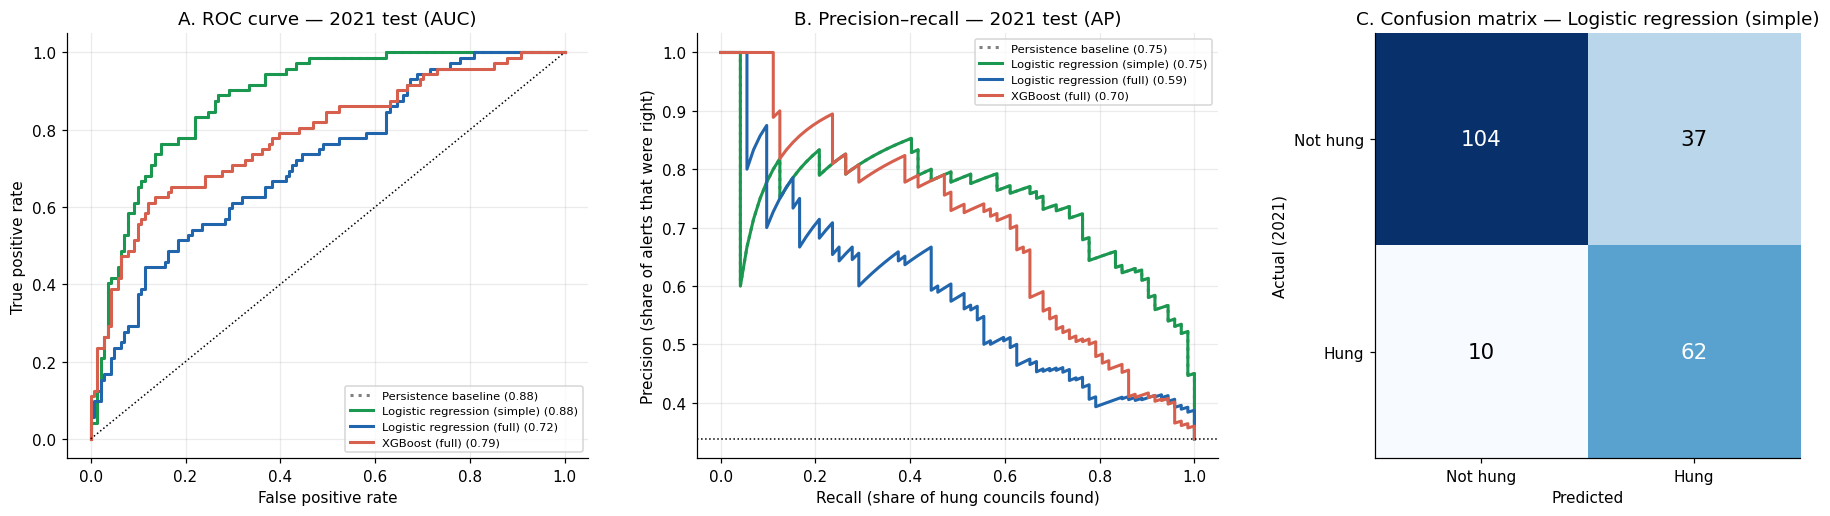

In [12]:
# ROC and precision-recall curves on the 2021 test, plus the selected model's confusion matrix.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
line_colours = {"Persistence baseline": "grey", "Logistic regression (simple)": "#1a9850",
                "Logistic regression (full)": "#2166ac", "XGBoost (full)": "#d6604d"}
for name, by_year in predictions.items():
    y_true, score = by_year[TEST_YEAR]
    style = ":" if name == "Persistence baseline" else "-"
    fpr, tpr, _ = roc_curve(y_true, score)
    axes[0].plot(fpr, tpr, ls=style, color=line_colours[name], lw=2, label=f"{name} ({roc_auc_score(y_true, score):.2f})")
    precision, recall, _ = precision_recall_curve(y_true, score)
    axes[1].plot(recall, precision, ls=style, color=line_colours[name], lw=2,
                 label=f"{name} ({average_precision_score(y_true, score):.2f})")
axes[0].plot([0, 1], [0, 1], color="black", ls=":", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="A. ROC curve — 2021 test (AUC)")
axes[1].axhline(y_test.mean(), color="black", ls=":", lw=1)
axes[1].set(xlabel="Recall (share of hung councils found)", ylabel="Precision (share of alerts that were right)",
            title="B. Precision–recall — 2021 test (AP)")
for ax in axes[:2]:
    ax.legend(fontsize=7.5)

y_true, score = predictions[selected][TEST_YEAR]
matrix = confusion_matrix(y_true, (score >= best_f1_threshold(selected)).astype(int))
axes[2].imshow(matrix, cmap="Blues")
for (i, j), value in np.ndenumerate(matrix):
    axes[2].text(j, i, value, ha="center", va="center", fontsize=14,
                 color="white" if value > matrix.max() / 2 else "black")
axes[2].set_xticks([0, 1], ["Not hung", "Hung"])
axes[2].set_yticks([0, 1], ["Not hung", "Hung"])
axes[2].set(xlabel="Predicted", ylabel="Actual (2021)", title=f"C. Confusion matrix — {selected}")
axes[2].grid(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_03_test_performance.png", dpi=200, bbox_inches="tight")
plt.show()

### What drives the risk of a hung council?
The simple logistic model can be read directly: the table shows its predicted risk for different current shares, and the chart compares that curve with the observed rate. For XGBoost we use **permutation importance** on the 2021 test: each feature is shuffled in turn, and a large drop in PR-AUC means the model relies on that feature.

leading party's share now (%),70,60,55,50,45,40,35
P(hung council next election),0.1,0.24,0.34,0.45,0.58,0.69,0.79


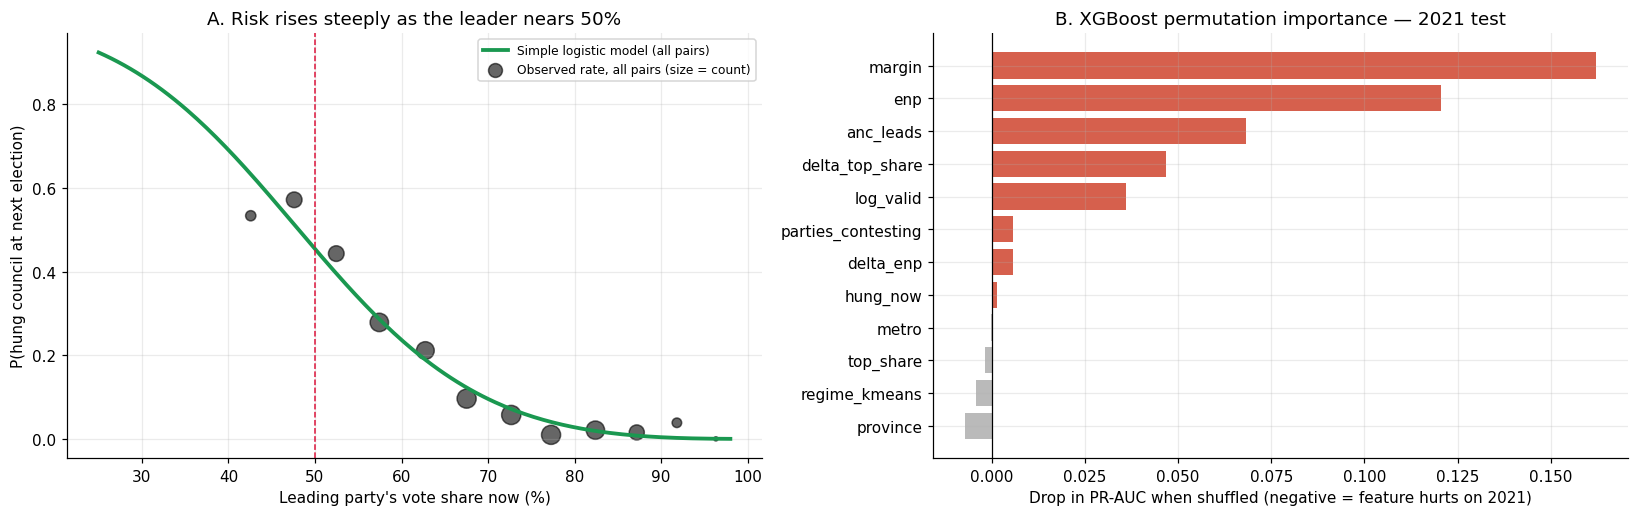

In [13]:
# The simple model, fitted on all pairs, read as "risk at the next election" for different current shares.
simple_fit = clone(logistic_simple).fit(pairs[FEATURES], pairs["hung_next"])
example = pd.DataFrame({f: np.nan for f in FEATURES}, index=range(7))
example["top_share"] = [0.70, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35]
display(pd.DataFrame({"leading party's share now (%)": (example["top_share"] * 100).astype(int),
                      "P(hung council next election)": simple_fit.predict_proba(example)[:, 1].round(2)}).set_index(
                      "leading party's share now (%)").T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# (A) Predicted probability curve against the observed hung rate in bins of leading-party share.
ax = axes[0]
grid = pd.DataFrame({f: np.nan for f in FEATURES}, index=range(200))
grid["top_share"] = np.linspace(0.25, 0.98, 200)
ax.plot(grid["top_share"] * 100, simple_fit.predict_proba(grid)[:, 1], color="#1a9850", lw=2.5,
        label="Simple logistic model (all pairs)")
bins = pd.cut(pairs["top_share"], np.arange(0.25, 1.01, 0.05))
observed = pairs.groupby(bins, observed=True).agg(x=("top_share", "mean"), rate=("hung_next", "mean"),
                                                  n=("hung_next", "size"))
observed = observed[observed["n"] >= 5]
ax.scatter(observed["x"] * 100, observed["rate"], s=observed["n"] * 1.5, color="black", alpha=0.6,
           label="Observed rate, all pairs (size = count)")
ax.axvline(50, color="crimson", ls="--", lw=1)
ax.set(xlabel="Leading party's vote share now (%)", ylabel="P(hung council at next election)",
       title="A. Risk rises steeply as the leader nears 50%")
ax.legend(fontsize=8)

# (B) Permutation importance for XGBoost on the 2021 test set.
ax = axes[1]
xgb_fit = clone(xgb_model).fit(X_train, y_train)
perm = permutation_importance(xgb_fit, X_test, y_test, scoring="average_precision", n_repeats=30, random_state=SEED)
perm = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
ax.barh(perm.index, perm.values, color=np.where(perm.values < 0, "#bababa", "#d6604d"))
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="Drop in PR-AUC when shuffled (negative = feature hurts on 2021)",
       title="B. XGBoost permutation importance — 2021 test")
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_04_drivers.png", dpi=200, bbox_inches="tight")
plt.show()

**Interpretation.** Chart A shows that the simple model's curve closely follows the observed rates. A leading party on 60% today carries about a 24% risk of a hung council at the next election; at 50% the risk is 45%; and at 40% it rises to 69%. The curve is steepest between 40% and 60%, so this is the zone where parties, journalists and the IEC should expect the most change.

Chart B shows that XGBoost spreads its reliance across margin, ENP, whether the ANC leads, and recent trends. Margin and ENP carry the same information as the leader's share (they are strongly correlated), which is why `top_share` itself appears unimportant here: shuffling one of them leaves the others to fill in. Several features (`province`, `regime_kmeans`, `metro`) have zero or slightly negative importance, meaning they add nothing or slightly *hurt* XGBoost's predictions for 2021, which is further evidence that the extra features did not generalise.

## Part C — Forecasting the regime at the next election (KMeans + XGBoost together)
Here the two methods work together without leakage: **KMeans defines the regimes**, and **XGBoost forecasts which regime each municipality will be in at the next election** from what we know about it now. We use the same features and the same untouched 2021 test, and compare against persistence ("the regime stays the same").

In [14]:
# Target: next election's KMeans regime (0 = Dominant, 1 = Competitive, 2 = Fragmented).
regime_code = {name: i for i, name in enumerate(REGIME_NAMES)}
y_train_r = train["regime_next"].astype(str).map(regime_code)
y_test_r = test["regime_next"].astype(str).map(regime_code)

xgb_regime = Pipeline([
    ("prep", clone(xgb_pipeline.named_steps["prep"])),
    ("model", XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", random_state=SEED,
                            n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.85,
                            colsample_bytree=0.8, min_child_weight=3)),
])
weights = y_train_r.map(len(y_train_r) / (3 * y_train_r.value_counts()))   # balance the three regimes
cv_f1 = cross_validate(xgb_regime, X_train, y_train_r, groups=groups, cv=cv, scoring="f1_macro",
                       params={"model__sample_weight": weights})["test_score"]
xgb_regime.fit(X_train, y_train_r, model__sample_weight=weights)
xgb_pred = xgb_regime.predict(X_test)
persist_pred = test["regime_kmeans"].map(regime_code)

regime_results = pd.DataFrame({
    "XGBoost": {"CV macro-F1 (train)": cv_f1.mean(), "test accuracy": accuracy_score(y_test_r, xgb_pred),
                "test macro-F1": f1_score(y_test_r, xgb_pred, average="macro"),
                "test balanced accuracy": balanced_accuracy_score(y_test_r, xgb_pred)},
    "Persistence (regime stays the same)": {
        "CV macro-F1 (train)": f1_score(y_train_r, train["regime_kmeans"].map(regime_code), average="macro"),
        "test accuracy": accuracy_score(y_test_r, persist_pred),
        "test macro-F1": f1_score(y_test_r, persist_pred, average="macro"),
        "test balanced accuracy": balanced_accuracy_score(y_test_r, persist_pred)}}).T
display(regime_results.round(3))
pd.DataFrame(confusion_matrix(y_test_r, xgb_pred), index=[f"actual {n}" for n in REGIME_NAMES],
             columns=[f"predicted {n}" for n in REGIME_NAMES])

,CV macro-F1 (train),test accuracy,test macro-F1,test balanced accuracy
XGBoost,0.721,0.638,0.631,0.664
Persistence (regime stays the same),0.634,0.662,0.654,0.750


,predicted Dominant,predicted Competitive,predicted Fragmented
actual Dominant,16,8,0
actual Competitive,5,41,10
actual Fragmented,4,50,79


**Interpretation.** XGBoost scores well in cross-validation (macro-F1 0.72 against 0.63 for persistence), but on the 2021 test it falls just short of simply assuming that each municipality keeps its current regime (macro-F1 0.63 against 0.65; balanced accuracy 0.66 against 0.75). The confusion matrix shows why: of the 133 municipalities that became Fragmented in 2021, XGBoost placed 50 in Competitive, because in the training period municipalities rarely moved to the fragmented regime so quickly. This mirrors the hung-council result: the 2021 shift was sharper than anything in the training history, and simpler, more stable signals held up better than complex models.

## Part D — The 2026 forecast
We retrain the selected model on **all four election pairs (2000→2021)**. Including 2016→2021 matters: it is the most recent pair and the only one in which hung councils were common. We then feed in each municipality's **2021 profile** to predict **November 2026**. XGBoost's score is shown alongside for comparison.

In [15]:
# Retrain on every available pair, then predict 2026 from each municipality's 2021 profile.
all_X, all_y = pairs[FEATURES], pairs["hung_next"]
final_model = clone(MODELS[selected]).fit(all_X, all_y)
xgb_final = clone(xgb_model).set_params(model__scale_pos_weight=(all_y == 0).sum() / all_y.sum()).fit(all_X, all_y)

forecast["P(hung 2026)"] = final_model.predict_proba(forecast[FEATURES])[:, 1]
forecast["XGBoost score"] = xgb_final.predict_proba(forecast[FEATURES])[:, 1]
forecast["risk band"] = pd.cut(forecast["P(hung 2026)"], bins=[0, 0.25, 0.5, 1.0],
                               labels=["Low", "Medium", "High"], include_lowest=True)

print(f"Final model: {selected}, retrained on {len(all_X)} election pairs")
print(f"Expected hung councils among these {len(forecast)} municipalities: {forecast['P(hung 2026)'].sum():.0f} "
      f"(hung after 2021: {forecast['hung_now'].sum()})")
rho = forecast[["P(hung 2026)", "XGBoost score"]].corr(method="spearman").iloc[0, 1]
print(f"Rank agreement between the selected model and XGBoost: Spearman ρ = {rho:.2f}")
display(forecast["risk band"].value_counts().reindex(["High", "Medium", "Low"]).to_frame("municipalities"))

# A few 2021 names are in capitals in the source data; we tidy them for display.
forecast["name"] = forecast["name"].where(~forecast["name"].str.isupper(), forecast["name"].str.title())
report_cols = ["name", "province", "leading_party", "top_share", "enp", "hung_now", "P(hung 2026)",
               "XGBoost score", "risk band"]
ranked = forecast.sort_values("P(hung 2026)", ascending=False)[report_cols]
ranked.to_csv(OUT_DIR / "forecast_hung_councils_2026.csv", index=False)
ranked.head(20).assign(top_share=lambda d: (d["top_share"] * 100).round(1)).round(3)

Final model: Logistic regression (simple), retrained on 869 election pairs
Expected hung councils among these 213 municipalities: 77 (hung after 2021: 72)
Rank agreement between the selected model and XGBoost: Spearman ρ = 0.75


,municipalities
risk band,
High,61
Medium,72
Low,80


,name,province,leading_party,top_share,enp,hung_now,P(hung 2026),XGBoost score,risk band
1123,Laingsburg,Western Cape,AFRICAN NATIONAL CONGRESS,25.6,4.777,1,0.917,0.986,High
1133,Beaufort West,Western Cape,AFRICAN NATIONAL CONGRESS,28.2,4.620,1,0.891,0.901,High
407,Okhahlamba,KwaZulu-Natal,INKATHA FREEDOM PARTY,30.7,4.427,1,0.858,0.661,High
1108,Oudtshoorn,Western Cape,DEMOCRATIC ALLIANCE,30.9,5.086,1,0.855,0.798,High
439,Newcastle,KwaZulu-Natal,AFRICAN NATIONAL CONGRESS,31.8,4.843,1,0.843,0.935,High
332,City of Johannesburg,Gauteng,AFRICAN NATIONAL CONGRESS,33.2,4.543,1,0.820,0.805,High
454,eDumbe,KwaZulu-Natal,NATIONAL FREEDOM PARTY,33.5,4.262,1,0.816,0.652,High
286,Metsimaholo,Free State,AFRICAN NATIONAL CONGRESS,34.7,3.863,1,0.795,0.386,High
1013,City of Tshwane,Gauteng,AFRICAN NATIONAL CONGRESS,34.8,4.031,1,0.793,0.821,High
1023,Cederberg,Western Cape,AFRICAN NATIONAL CONGRESS,35.6,3.968,1,0.778,0.883,High


,name,province,leading_party,top_share,P(hung 2026)
868,Tsantsabane,Northern Cape,AFRICAN NATIONAL CONGRESS,50.2,0.449
310,Lesedi,Gauteng,AFRICAN NATIONAL CONGRESS,50.5,0.443
880,Sol Plaatje,Northern Cape,AFRICAN NATIONAL CONGRESS,50.5,0.442
540,Ndwedwe,KwaZulu-Natal,AFRICAN NATIONAL CONGRESS,50.6,0.441
502,uMfolozi,KwaZulu-Natal,INKATHA FREEDOM PARTY,50.6,0.440
807,KHâI-MA,Northern Cape,AFRICAN NATIONAL CONGRESS,50.7,0.438
1093,Hessequa,Western Cape,DEMOCRATIC ALLIANCE,50.7,0.437
734,Emalahleni,Mpumalanga,AFRICAN NATIONAL CONGRESS,50.8,0.434
424,Nqutu,KwaZulu-Natal,INKATHA FREEDOM PARTY,51.0,0.429
246,Setsoto,Free State,AFRICAN NATIONAL CONGRESS,51.1,0.427


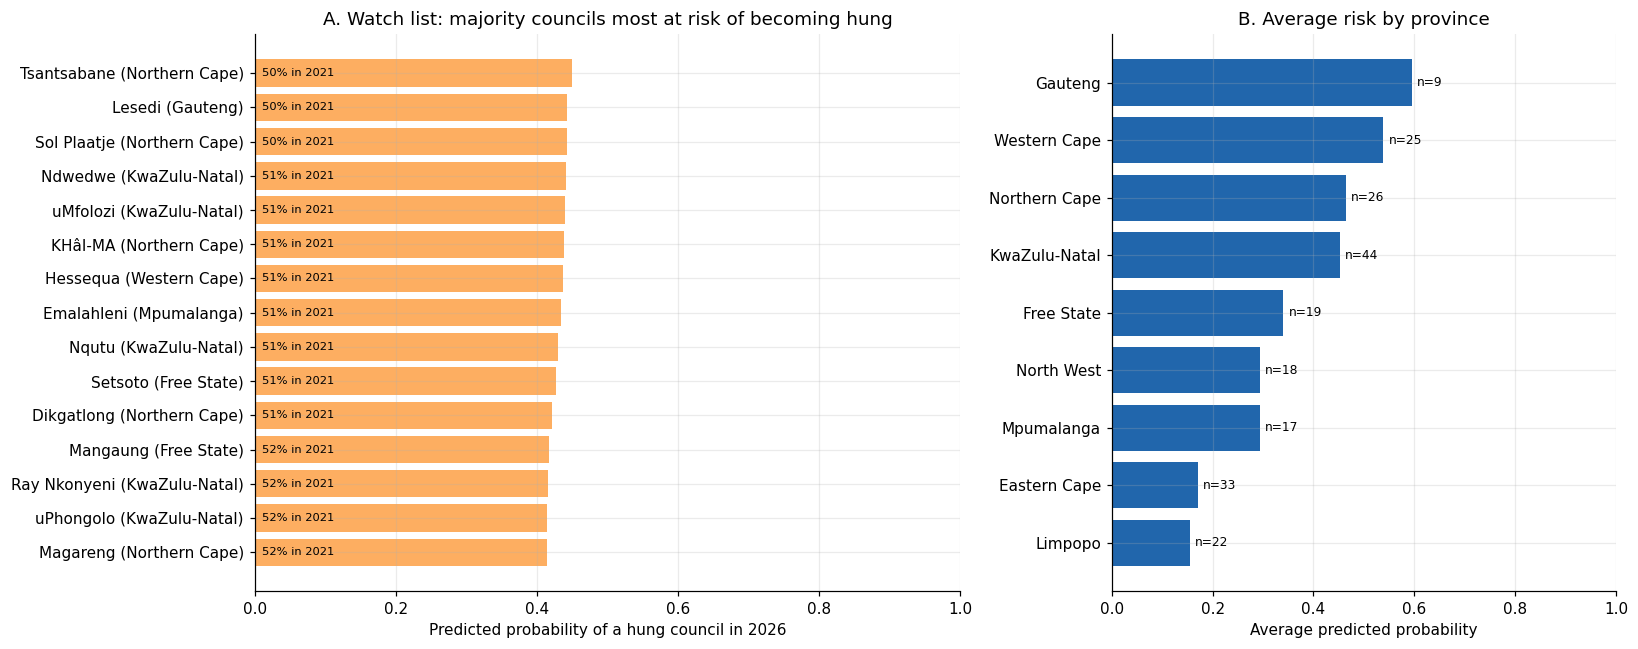

In [16]:
# Watch list: councils that still had a majority in 2021 but are most at risk of losing it in 2026.
watch_list = ranked[ranked["hung_now"] == 0].head(15)
display(watch_list[["name", "province", "leading_party", "top_share", "P(hung 2026)"]]
        .assign(top_share=lambda d: (d["top_share"] * 100).round(1)).round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
wl = watch_list.iloc[::-1]
ax.barh(wl["name"] + " (" + wl["province"] + ")", wl["P(hung 2026)"], color="#fdae61")
for i, share in enumerate(wl["top_share"]):
    ax.text(0.01, i, f"{share * 100:.0f}% in 2021", va="center", fontsize=7.5)
ax.set(xlabel="Predicted probability of a hung council in 2026", xlim=(0, 1),
       title="A. Watch list: majority councils most at risk of becoming hung")

ax = axes[1]
by_province = forecast.groupby("province")["P(hung 2026)"].agg(["mean", "size"]).sort_values("mean")
ax.barh(by_province.index, by_province["mean"], color="#2166ac")
for i, (mean, size) in enumerate(zip(by_province["mean"], by_province["size"])):
    ax.text(mean + 0.01, i, f"n={size}", va="center", fontsize=8)
ax.set(xlabel="Average predicted probability", xlim=(0, 1), title="B. Average risk by province")
plt.tight_layout()
plt.savefig(FIG_DIR / "ml_05_forecast_2026.png", dpi=200, bbox_inches="tight")
plt.show()

### Scenario analysis: what if support keeps falling?
The model learns from the past, but 2026 may bring another national swing like 2021. We therefore test scenarios in which **every leading party loses the same number of percentage points** (a *uniform swing*) before applying the model. For reference, we first measure the median change in leading-party share between 2016 and 2021.

In [17]:
# Uniform-swing scenarios: subtract the same number of points from every leading party's 2021 share.
shares = panel.pivot(index="panel_id", columns="year", values="top_share")[[2016, 2021]].dropna()
swing_2021 = (shares[2021] - shares[2016]).median() * 100
print(f"Reference: median change in leading-party share, 2016 → 2021 = {swing_2021:.1f} points")

scenarios = {}
for swing in [0, 2, 4, 6, 8, 10]:
    shifted = forecast[FEATURES].copy()
    shifted["top_share"] = (shifted["top_share"] - swing / 100).clip(0.01, 0.99)
    p = final_model.predict_proba(shifted)[:, 1]
    scenarios[f"−{swing} points"] = {"expected hung councils": round(p.sum()),
                                     "municipalities with P ≥ 0.5": int((p >= 0.5).sum())}
scenarios = pd.DataFrame(scenarios).T
scenarios.index.name = "swing against every leading party"
scenarios

Reference: median change in leading-party share, 2016 → 2021 = -6.8 points


,expected hung councils,municipalities with P ≥ 0.5
swing against every leading party,,
−0 points,77,61
−2 points,84,72
−4 points,92,89
−6 points,100,104
−8 points,108,113
−10 points,117,122


In [18]:
# We save the final models, KMeans and the feature list, ready for the deployment app.
joblib.dump({"hung_model": final_model, "hung_model_name": selected, "xgboost_model": xgb_final,
             "features": FEATURES, "kmeans": kmeans, "kmeans_scaler": scaler,
             "cluster_to_name": cluster_to_name, "regime_names": REGIME_NAMES},
            MODEL_DIR / "lge_2026_models.joblib")
print("Saved: models/lge_2026_models.joblib and outputs/forecast_hung_councils_2026.csv")

Saved: models/lge_2026_models.joblib and outputs/forecast_hung_councils_2026.csv


## Conclusions
1. **KMeans found three stable, meaningful regimes** (Dominant, Competitive, Fragmented). The Fragmented regime is centred on a leading party with about 51% of the vote, and its share of municipalities rose from 25% in 2000 to 62% in 2021.
2. **The most reliable predictor of a hung council is how close the leading party is to 50% today.** After comparing four approaches with forward-chaining validation, the simple logistic model was selected, and on the unseen 2021 election it reached ROC-AUC 0.88 and PR-AUC 0.75, correctly flagging 62 of the 72 councils that became hung.
3. **More complex models did not generalise across elections.** XGBoost looked best under standard cross-validation but was outperformed on future elections. Validating in time order, rather than only with random folds, was essential to seeing this.
4. **2026 forecast.** Across all 213 municipalities, the model expects about **77 hung councils** (72 were hung after 2021), with 61 at high risk. The highest-risk councils include several Western Cape municipalities (Laingsburg, Beaufort West, Oudtshoorn, Knysna), the Gauteng metros (Johannesburg, Tshwane, Ekurhuleni) and several KwaZulu-Natal municipalities. The watch list highlights majority councils sitting just above 50%, such as **Mangaung, Sol Plaatje, Emalahleni, Lesedi and Hessequa**.
5. **Scenarios matter.** If leading parties lose another 6 points, similar to the median drop of 6.8 points from 2016 to 2021, the expected number of hung councils rises to about 100.

### Recommendations
- **Voters and journalists** can use the watch list to focus attention on councils where the 2026 result is most likely to change who governs.
- **Parties and the IEC** should prepare for coalition governance in far more municipalities than before, especially in Gauteng, the Western Cape, the Northern Cape and KwaZulu-Natal, which have the highest average risk.
- **For deployment**, the saved model and the uniform-swing scenario can power an interactive app in which users choose a municipality, adjust the swing, and see the risk update.

## Limitations
- **The 50% rule is an approximation** of a hung council; exact seat allocation (rounding, ward seats and small-party thresholds) can differ slightly.
- **Few time periods.** We have only four election pairs, so the model has seen limited variety in political conditions. The backtest shows how this affects reliability.
- **A changing landscape.** Hung councils jumped from 13% to 30% in 2021; if 2026 brings another structural shift (new parties, coalition fallout), the forecast probabilities may be too low or too high overall, even if the *ranking* of municipalities remains useful.
- **Boundary changes** mean a municipality's history may partly reflect a different area before re-demarcation.
- **No polling or candidate data.** The model uses only past election results; local events (scandals, service-delivery protests, new parties) are not captured.

## References
- Electoral Commission of South Africa (IEC). *Municipal election results, 2000–2021.* https://results.elections.org.za
- Chen, T. & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD Conference*, 785–794.
- Laakso, M. & Taagepera, R. (1979). "Effective" number of parties. *Comparative Political Studies*, 12(1), 3–27.
- Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65.
- Hubert, L. & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218. (Adjusted Rand index.)
- Saito, T. & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLoS ONE*, 10(3), e0118432.
- Pedregosa, F. et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Python packages: pandas, NumPy, Matplotlib, scikit-learn, XGBoost, joblib.